# **Applied Data Science in Medicine & Psychology - Assignment 6**
## Numpy and Scipy
---
**Deadline: 13.06.2023, 23:59**
### **General setup and submission**
1. Save an editable copy of this notebook to your Google Drive ``File`` $\rightarrow$ ``Save a copy in Drive`` and remove the automatically appended "Copy of" text. **Do not change the file name**.
2. Work on the assignment in the *copied* version of the notebook. Make sure that you **replace** all parts of the tasks indicated with *YOUR CODE HERE* and **raise NotImplementedError()** (otherwise this causes an error in your implementation) or *YOUR ANSWER HERE* with your solution.
3. If you take a break during the implementation, you can save the current status of your work in your repository following the submission instructions below. When you continue working on the assignment, do this in the version of the notebook that you saved in your Google Drive (access from your Google Colab account) or your repository.
4. After finishing the assignment submit your assignment as follows:
    * Check that everything runs as expected. To do that select in the menubar ``Runtime`` $\rightarrow$ ``Restart and run all``. This will clear all your local variables and runs your notebook from the beginning
    * Save your notebook, click ``File`` $\rightarrow$ ``Save``
    * Click ``File`` $\rightarrow$ ``Save a copy in GitHub``
    * Select ``digikolleg-data-science-psychology/06_numpy_scipy-<username>`` from the Repository drop-down menu 
    * Type ``06_numpy_scipy.ipynb`` into the File path text box
    * Optionally, you may enter a description into the "Commit message" text box (like: "solved task 1" or "ready for grading")
    * Make sure that the "Include a link to Colaboratory" box is checked
    * Press "Ok"
    * A new tab or window should open up, displaying your submitted notebook within your GitHub repository

Before the assignment deadline, you can re-submit your assignment as often as you would like. This will update the copy of your assignment file in your assignment's repository.

### **Assignment Description**
***General description... TODO***

#### **Assignment goals**
You are going to learn the following things in this assignment:
1. ***TODO***
2. ***TODO***

#### **Assignment point value**
This assignment is worth a total (up to) ***X TODO*** point***(s) TODO***. If your code passes all of the manual and automatic tests you will receive full credit.

### **Tasks**
Make sure that you now work on your *copied* version of this assignment's notebook.

#### 0. Imports and Setup
Please **run** the cell below to import the libraries needed for this assignment.

In [88]:
import matplotlib.pyplot as plt
import numpy as np
!pip install biopsykit
import biopsykit as bp
from scipy import signal
from scipy.datasets import electrocardiogram
%matplotlib widget


[notice] A new release of pip available: 22.3.1 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### XX. Perceived Stress Scale
In this task we compute the Perceived Stress Scale (PSS). The PSS is a widely used self-report questionnaire with adequate reliability and validity asking about how stressful a person has found his/her life during the previous month. The PSS consists of the subscales Perceived Helplessness and Perceived Self-Efficacy. The participant is asked to rate questions like "In the last month, how often have you been upset because of something that happened unexpectedly?" from 0 (never) to 4 (very often). Some of the questions are negatively and some positively formulated.

Scores can range between 0 and 40, with higher scores indicating higher perceived stress:
* 0-13: low stress
* 14-26: moderate stress
* 27-40: high perceived stress

Vp: german Versuchsperson similar to participant

In [85]:
data = bp.example_data.get_questionnaire_example()
data, _ = bp.questionnaires.utils.find_cols(data, starts_with="PSS")
participants = list(data.index)
data.head()

,PSS_01,PSS_02,PSS_03,PSS_04,PSS_05,PSS_06,PSS_07,PSS_08,PSS_09,PSS_10
subject,,,,,,,,,,
Vp01,3,2,3,3,2,2,2,2,3,1
Vp02,1,1,1,3,2,1,3,3,1,0
Vp03,2,3,3,2,2,2,1,1,3,1
Vp04,2,2,2,3,2,2,3,2,2,1
Vp05,0,2,2,3,2,1,3,3,2,1


In [68]:
data_pss = data.to_numpy()
data_pss[:5, :] # just for visualization

array([[3, 2, 3, 3, 2, 2, 2, 2, 3, 1],
       [1, 1, 1, 3, 2, 1, 3, 3, 1, 0],
       [2, 3, 3, 2, 2, 2, 1, 1, 3, 1],
       [2, 2, 2, 3, 2, 2, 3, 2, 2, 1],
       [0, 2, 2, 3, 2, 1, 3, 3, 2, 1]], dtype=int64)

In [13]:
### BEGIN SOLUTION
def check_score_range(data, score_range):
    return ((data >= score_range[0]) & (data <= score_range[1])).all()
### END SOLUTION

In [11]:
data_test = np.random.randint(low=0, high=5, size=[5, 5])
assert check_score_range(data_test, [0, 4])
assert check_score_range(data_test, [0, 3]) == False

In [25]:
### BEGIN SOLUTION
def invert(data, score_range):
    return score_range[1] - data[:] + score_range[0]
### END SOLUTION

In [36]:
data_test = np.array([[1, 3], [2, 4]])
assert np.array_equal(invert(data_test, [0, 5]), np.array([[4, 2], [3, 1]]))
### BEGIN HIDDEN TESTS
assert np.array_equal(invert(data_test, [0, 10]), np.array([[9, 7], [8, 6]]))
### END HIDDEN TESTS

In [37]:
def calc_score(data):
    return data.sum(axis=1)

In [41]:
data_test = np.array([[1, 3], [2, 4]])
assert np.array_equal(calc_score(data_test), np.array([4, 6]))

In [69]:
score_range = [0, 4]
subscales = {"Helpless": [0, 1, 2, 5, 8, 9], "SelfEff": [3, 4, 6, 7]}

### BEGIN SOLUTION
def calc_pss(data, score_range, subscales):
    data_helpless = data[:, subscales["Helpless"]]
    data_selfeff = data[:, subscales["SelfEff"]]

    data_helpless_score = calc_score(data_helpless)
    data_selfeff = invert(data_selfeff, score_range)
    data_selfeff_score = calc_score(data_selfeff)

    data_total = np.concatenate([data_helpless_score[:, np.newaxis], data_selfeff_score[:, np.newaxis]], axis=1)
    data_total_score = calc_score(data_total)   
    
    return data_total_score
### END SOLUTION

#### 2. ECG Analysis

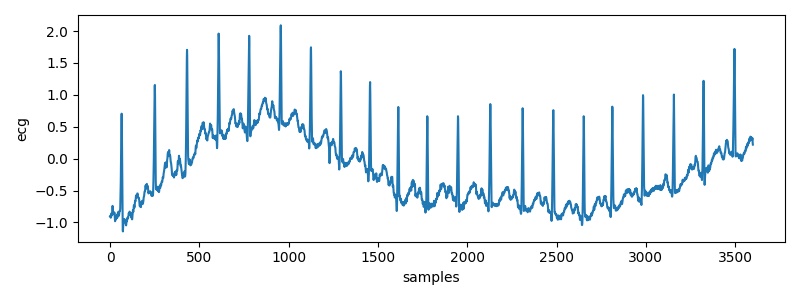

In [93]:
# run this cell to visualize the ecg
fs = 360
ecg = electrocardiogram()[2000:5600]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ecg)
ax.set_xlabel("samples")
ax.set_ylabel("ecg")
fig.tight_layout()

##### 2.1 Create a Butterworth filter ``sos`` to remove the baseline and high-frequency artifacts using the [scipy.signal.butter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html) implementation with the following parameters:
* Order of the filter: 2
* Critical frequencies: 
    * baseline artifacts: 0.5 Hz
    * high-frequency artifacts: 50 Hz
* Filter type: bandpass
* Sampling Frequency: Sampling Frequency of the ECG
* Output type: sos

Use [scipy.signal.sosfiltfilt](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.sosfiltfilt.html) for applying the filter to the ecg signal and save the result in the variable ``ecg_filtered``:

**Hint**: Have a look how ``scipy.signal`` is imported.

In [90]:
### BEGIN SOLUTION
sos = signal.butter(N=2, Wn=[0.5, 50], btype='bandpass', fs=fs, output='sos')
ecg_filtered = signal.sosfiltfilt(sos, ecg)
### END SOLUTION

In [104]:
assert len(ecg_filtered) == 3600
assert np.min(ecg_filtered) >= -1 and np.max(ecg_filtered) <= 1.8

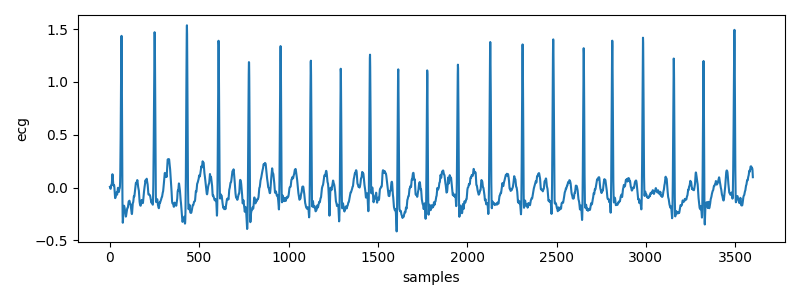

In [105]:
# run this cell to visualize the filtered ecg
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ecg_filtered)
ax.set_xlabel("samples")
ax.set_ylabel("ecg")
fig.tight_layout()

##### 2.2 One parameter that is derived from an ecg in almost every analysis pipeline is the heart rate which is calculated based on the differences between the R peaks (highest ecg peaks). Use [scipy.signal.find_peaks](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html) to identify all the relevant peaks in ``ecg_filtered``. Play around with the functions parameters such that only the R peaks and not all of peaks in the signal are identified. Save your results in the variable ``r_peaks``:

In [106]:
### BEGIN SOLUTION
r_peaks, _ = signal.find_peaks(ecg_filtered, height=1)
### END SOLUTION

In [112]:
assert type(r_peaks) == np.ndarray
assert len(r_peaks) == 21

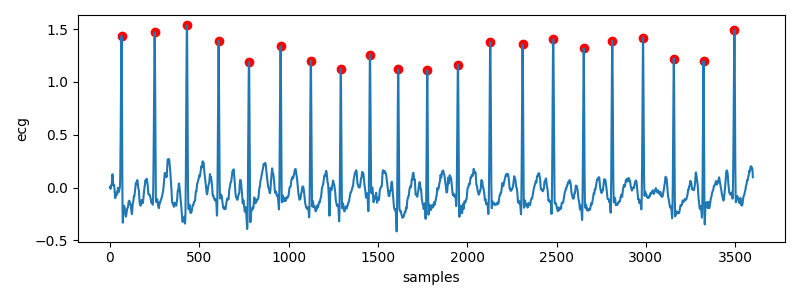

In [117]:
# run this cell to visualize the filtered ecg with all identified r_peaks
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ecg_filtered)
ax.scatter(r_peaks, ecg_filtered[r_peaks], color='red')
ax.set_xlabel("samples")
ax.set_ylabel("ecg")
fig.tight_layout()

##### 2.3 To verify results it is often helpful to visualize a signal not with the samples on the x-axis but over time in seconds. Use the [numpy.linspace](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) function to generate a vector called ``t`` that corresponds to the time:

**Hint**: A sampling frequency of 360 Hz means that 360 samples are recorded in 1 second. Our signal is 10 seconds long, therefore it consists of 3600 samples.

In [130]:
### BEGIN SOLUTION
t = np.linspace(start=0, stop=len(ecg)/fs, num=len(ecg))
### END SOLUTION

In [129]:
assert len(t) == 3600
assert np.min(t) == 0 and np.max(t) <= 10

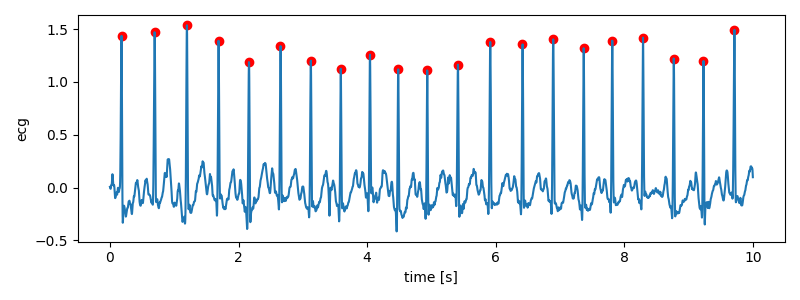

In [131]:
# run this cell to visualize the filtered ecg with all identified r_peaks over time
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, ecg_filtered)
ax.scatter(r_peaks/fs, ecg_filtered[r_peaks], color='red')
ax.set_xlabel("time [s]")
ax.set_ylabel("ecg")
fig.tight_layout()

##### 2.4 Create a function called ``calc_hr_bpm`` that calculates the heartrate of an ecg in beats per minute (bpm) and takes the parameter ``r_peaks`` and ``fs``
* ``r_peaks``: Array with R peak positions in samples
* ``fs``: Sampling frequency of the ecg
* You can use [numpy.diff](https://numpy.org/doc/stable/reference/generated/numpy.diff.html) and [numpy.mean](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) in your implementation

**Hint**: 1 Hz corresponds to 60 bpm.

In [132]:
### BEGIN SOLUTION
def calc_hr_bpm(r_peaks, fs):
    r_peaks_diff = np.diff(r_peaks)
    hr_samples = np.mean(r_peaks_diff)
    hr_s = fs / hr_samples
    hr_bpm = hr_s * 60
    return hr_bpm
### END SOLUTION   

In [137]:
assert calc_hr_bpm(np.array([300, 600, 900]), 300) == 60
### BEGIN HIDDEN TESTS
assert calc_hr_bpm(np.array([200, 1200, 2200]), 500) == 30
### END HIDDEN TESTS

##### 2.5 Calculate the heart rate of the ecg in bpm using ``calc_hr_bpm`` and ``r_peaks`` and save it in the variable ``hr``. Can you verify this result with the plot of the ecg over time?

In [139]:
### BEGIN SOLUTION
hr = calc_hr_bpm(r_peaks, fs)
### END SOLUTION

In [140]:
assert hr > 125 and hr < 127